# Assignment 1

You only need to write one line of code for each question. When answering questions that ask you to identify or interpret something, the length of your response doesn’t matter. For example, if the answer is just ‘yes,’ ‘no,’ or a number, you can just give that answer without adding anything else.

We will go through comparable code and concepts in the live learning session. If you run into trouble, start by using the help `help()` function in Python, to get information about the datasets and function in question. The internet is also a great resource when coding (though note that **no outside searches are required by the assignment!**). If you do incorporate code from the internet, please cite the source within your code (providing a URL is sufficient).

Please bring questions that you cannot work out on your own to office hours, work periods or share with your peers on Slack. We will work with you through the issue.

### Classification using KNN

Let's set up our workspace and use the **Wine dataset** from `scikit-learn`. This dataset contains 178 wine samples with 13 chemical features, used to classify wines into different classes based on their origin.

The **response variable** is `class`, which indicates the type of wine. We'll use all of the chemical features to predict this response variable.

In [107]:
# Import standard libraries
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import recall_score, precision_score
from sklearn.model_selection import cross_validate
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

In [108]:
from sklearn.datasets import load_wine

# Load the Wine dataset
wine_data = load_wine()

# Convert to DataFrame
wine_df = pd.DataFrame(wine_data.data, columns=wine_data.feature_names)

# Bind the 'class' (wine target) to the DataFrame
wine_df["class"] = wine_data.target

# Display the DataFrame
wine_df


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2


#### **Question 1:** 
#### Data inspection

Before fitting any model, it is essential to understand our data. **Use Python code** to answer the following questions about the **Wine dataset**:

_(i)_ How many observations (rows) does the dataset contain?

In [109]:
wine_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  class

In [110]:
wine_df.describe()
# Your answer here = 178 rows 

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


In [111]:
# another way: 
wine_df.shape[0]
# Your answer here

178

_(ii)_ How many variables (columns) does the dataset contain?

In [112]:
# Your answer here
# see above info method → 14 variables 
wine_df.shape[1]

14

_(iii)_ What is the 'variable type' of the response variable `class` (e.g., 'integer', 'category', etc.)? What are the 'levels' (unique values) of the variable?

In [113]:
# Your answer here
# see above info.metod →  class = int
print(wine_df["class"])


0      0
1      0
2      0
3      0
4      0
      ..
173    2
174    2
175    2
176    2
177    2
Name: class, Length: 178, dtype: int64


In [114]:
# another way: using dtype method
wine_df["class"].dtype 


dtype('int64')


_(iv)_ How many predictor variables do we have (Hint: all variables other than `class`)? 

In [115]:
# Your answer here
# see above info.metod →  number of predictors = 13
#another way
wine_df.shape[1] - 1

13

You can use `print()` and `describe()` to help answer these questions.

#### **Question 2:** 
#### Standardization and data-splitting

Next, we must preform 'pre-processing' or 'data munging', to prepare our data for classification/prediction. For KNN, there are three essential steps. A first essential step is to 'standardize' the predictor variables. We can achieve this using the scaler method, provided as follows:

In [116]:
# Select predictors (excluding the last column)
predictors = wine_df.iloc[:, :-1]

# Standardize the predictors
scaler = StandardScaler()
predictors_standardized = pd.DataFrame(scaler.fit_transform(predictors), columns=predictors.columns)

# Display the head of the standardized predictors
print(predictors_standardized.head())

    alcohol  malic_acid       ash  alcalinity_of_ash  magnesium  \
0  1.518613   -0.562250  0.232053          -1.169593   1.913905   
1  0.246290   -0.499413 -0.827996          -2.490847   0.018145   
2  0.196879    0.021231  1.109334          -0.268738   0.088358   
3  1.691550   -0.346811  0.487926          -0.809251   0.930918   
4  0.295700    0.227694  1.840403           0.451946   1.281985   

   total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
0       0.808997    1.034819             -0.659563         1.224884   
1       0.568648    0.733629             -0.820719        -0.544721   
2       0.808997    1.215533             -0.498407         2.135968   
3       2.491446    1.466525             -0.981875         1.032155   
4       0.808997    0.663351              0.226796         0.401404   

   color_intensity       hue  od280/od315_of_diluted_wines   proline  
0         0.251717  0.362177                      1.847920  1.013009  
1        -0.293321  0.406051

In [117]:
### another way from our classification notebook
# Create a copy of the original 'cancer' dataframe to ensure we're not modifying the original data
standardized_wine_df = wine_df.copy()

# Specify the columns that we do NOT want to scale (class columns)
columns_to_exclude = ["class"]

# Select the columns that we want to scale by excluding the 'id' and 'diagnosis' columns
# This will return a list of the numeric columns we need to scale
columns_to_scale = standardized_wine_df.columns.difference(columns_to_exclude)

# Initialize the StandardScaler to standardize the selected numeric columns
scaler = StandardScaler()

# Apply the scaler to the selected columns. This transforms the data so that each feature
# has a mean of 0 and a standard deviation of 1, which is essential to prevent larger
# scale features from dominating the analysis, especially for distance-based algorithms like KNN.
standardized_wine_df[columns_to_scale] = scaler.fit_transform(wine_df[columns_to_scale])

# Output the standardized dataframe with the scaled numeric columns
standardized_wine_df


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009,0
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242,0
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148,0
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574,0
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,0.876275,2.974543,0.305159,0.301803,-0.332922,-0.985614,-1.424900,1.274310,-0.930179,1.142811,-1.392758,-1.231206,-0.021952,2
174,0.493343,1.412609,0.414820,1.052516,0.158572,-0.793334,-1.284344,0.549108,-0.316950,0.969783,-1.129518,-1.485445,0.009893,2
175,0.332758,1.744744,-0.389355,0.151661,1.422412,-1.129824,-1.344582,0.549108,-0.422075,2.224236,-1.612125,-1.485445,0.280575,2
176,0.209232,0.227694,0.012732,0.151661,1.422412,-1.033684,-1.354622,1.354888,-0.229346,1.834923,-1.568252,-1.400699,0.296498,2


In [118]:
wine_df

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2


In [119]:
#my experiment, not related to the assigment
# check for observation 0 in alcohol:

df = pd.DataFrame(wine_df) 
value_alcohol_0 = df.iloc[0,0]
value_alcohol_0



np.float64(14.23)

In [120]:
# Z=X-M/σ

(value_alcohol_0 - wine_df["alcohol"].mean())/wine_df["alcohol"].std()

np.float64(1.5143407672921376)

In [121]:
# in the table the standardized value for alcohol 0 observation is 1.518613 and my the culculation above value is : 1.5143407672921376 
# how can we explain discrepancy

(i) Why is it important to standardize the predictor variables?

> When standardizing the predictor values (i.e., transforming them into Z-scores with a mean of 0 and a standard deviation of 1), we ensure that each predictor's impact on the response variable is not influenced by its scale (as in the case of magnesium, which is measured in units of tens, while the range of total phenols is typically less than 10. We would like yo prevent a case in which magnesium overpowers the model).In other words, we do not want magnesium to dominate the distance calculations 

(ii) Why did we elect not to standard our response variable `Class`?

> it is only one variable, better to preserve its original value 

(iii) A second essential step is to set a random seed. Do so below (Hint: use the random.seed function). Why is setting a seed important? Is the particular seed value important? Why or why not?

In [122]:
np.random.seed(123)

>  We aim to ensure randomness when splitting the data to minimize bias. At the same time, we want to maintain reproducibility while building our KNN model. This allows us to inspect, revisit, and evaluate the process, ensuring we can access the same observations if we need to examine how we constructed our classifier.

(iv) A third essential step is to split our standardized data into separate training and testing sets. We will split into 75% training and 25% testing. The provided code randomly partitions our data, and creates linked training sets for the predictors and response variables. 

Extend the code to create a non-overlapping test set for the predictors and response variables.

In [123]:
#one way:
# set the seed for reproducibility
np.random.seed(123)

#split the data
wine_df_train, wine_df_test = train_test_split(
    standardized_wine_df, train_size=0.75, stratify=standardized_wine_df["class"]
)

print (len(wine_df_train), len (wine_df_test))

133 45


In [124]:
#another way
# set a seed for reproducibility
np.random.seed(123)

# split the data into a training and testing set. hint: use train_test_split !
# Your code here ...
X_train, X_test, y_train, y_test = train_test_split(
    predictors_standardized, wine_df["class"], train_size=0.75, stratify=wine_df["class"]
)
print (len(X_train), len (X_test), len (y_train), len (y_test))



133 45 133 45


In [125]:
wine_df_train.info()


<class 'pandas.core.frame.DataFrame'>
Index: 133 entries, 78 to 66
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       133 non-null    float64
 1   malic_acid                    133 non-null    float64
 2   ash                           133 non-null    float64
 3   alcalinity_of_ash             133 non-null    float64
 4   magnesium                     133 non-null    float64
 5   total_phenols                 133 non-null    float64
 6   flavanoids                    133 non-null    float64
 7   nonflavanoid_phenols          133 non-null    float64
 8   proanthocyanins               133 non-null    float64
 9   color_intensity               133 non-null    float64
 10  hue                           133 non-null    float64
 11  od280/od315_of_diluted_wines  133 non-null    float64
 12  proline                       133 non-null    float64
 13  class     

In [126]:
wine_df_train["class"].value_counts(normalize=True) #culculate the propotion of each win class 

class
1    0.398496
0    0.330827
2    0.270677
Name: proportion, dtype: float64

#### **Question 3:**
#### Model initialization and cross-validation
We are finally set to fit the KNN model. 


Perform a grid search to tune the `n_neighbors` hyperparameter using 10-fold cross-validation. Follow these steps:

1. Initialize the KNN classifier using `KNeighborsClassifier()`.
2. Define a parameter grid for `n_neighbors` ranging from 1 to 50.
3. Implement a grid search using `GridSearchCV` with 10-fold cross-validation to find the optimal number of neighbors.
4. After fitting the model on the training data, identify and return the best value for `n_neighbors` based on the grid search results.

In [127]:
# Your code here...
knn = KNeighborsClassifier()

In [128]:
knn = KNeighborsClassifier(n_neighbors=50)   
knn
 

,n_neighbors,50
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [129]:
# I see here that the metric  is "minkowski" → should I change  to Euclidian?

In [130]:
#instead of writing manually the list of columns I use tolist metods 
df = pd.DataFrame(wine_df)

column_names_list = df.columns.tolist()

column_names_list

['alcohol',
 'malic_acid',
 'ash',
 'alcalinity_of_ash',
 'magnesium',
 'total_phenols',
 'flavanoids',
 'nonflavanoid_phenols',
 'proanthocyanins',
 'color_intensity',
 'hue',
 'od280/od315_of_diluted_wines',
 'proline',
 'class']

In [131]:
# then I use list method to get the list of predictors
column_names_list_exresponse = column_names_list[0:13]
column_names_list_exresponse

['alcohol',
 'malic_acid',
 'ash',
 'alcalinity_of_ash',
 'magnesium',
 'total_phenols',
 'flavanoids',
 'nonflavanoid_phenols',
 'proanthocyanins',
 'color_intensity',
 'hue',
 'od280/od315_of_diluted_wines',
 'proline']

In [132]:
knn.fit(X=wine_df_train[column_names_list_exresponse], y=wine_df_train["class"])

,n_neighbors,50
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [133]:
wine_df_test['predicted class'] = knn.predict(wine_df_test[column_names_list_exresponse]) # inquire the data/predictons before splitting to 10 cross validtions
wine_df_test

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class,predicted class
102,-0.816038,0.102021,0.341713,0.451946,-0.122282,0.424438,0.081051,-0.176095,-0.492158,-0.976782,-0.690784,1.085200,-0.983669,1,1
84,-1.433671,-1.298334,0.780354,-0.448909,-0.403135,-0.152402,0.181447,-1.143031,1.330009,-0.868639,-0.734657,0.661468,-0.722540,1,1
96,-1.470729,-0.194208,1.365208,0.602088,2.405399,-1.113800,-1.043392,-1.787656,-0.054137,-1.106553,-0.032683,-0.496736,-0.388168,1,1
65,-0.778980,-1.011081,0.707247,-0.418881,-0.122282,0.200111,0.623193,0.065639,0.856946,-0.198156,1.020278,-0.440238,-0.219390,1,1
79,-0.371343,1.376703,0.122392,1.052516,0.088358,0.857067,0.522796,0.549108,0.629175,-1.076273,1.020278,0.732090,-0.904056,1,1
17,1.024507,-0.687923,0.926567,0.151661,1.071345,1.049347,1.376168,0.307374,0.226196,0.666984,0.757038,-0.058878,1.220001,0,0
109,-1.717782,-0.885409,1.218995,0.151661,-0.403135,0.712858,0.894264,-0.578985,1.575301,-1.041667,0.011190,0.915707,-0.213021,1,1
113,-1.964835,-1.432983,0.487926,0.451946,-0.824415,0.296251,-0.019346,0.468530,-0.264388,-0.855662,0.625418,-0.426113,-0.996407,1,1
28,1.073917,-0.391694,1.584529,-0.028510,0.509638,1.049347,0.944462,0.065639,0.296279,-0.241413,1.283518,1.113449,0.535335,0,0
159,0.592164,-0.598156,0.999674,0.902373,-0.754202,0.488531,-0.932956,1.274310,1.224884,2.894719,-1.699872,-1.174708,-0.404091,2,2


In [134]:
wine_df_test.shape[0] #checking number of rows 

45

In [135]:
wine_df_test[['class','predicted class']]

,class,predicted class
102,1,1
84,1,1
96,1,1
65,1,1
79,1,1
17,0,0
109,1,1
113,1,1
28,0,0
159,2,2


In [136]:
knn.score(
    wine_df_test[column_names_list_exresponse], wine_df_test['class']
)

0.9555555555555556

In [137]:
pd.crosstab(
    wine_df_test['class'],
    wine_df_test['predicted class'],
    rownames = ['Actual'],
    colnames = ['Predicted']
)

Predicted,0,1,2
Actual,,,
0,15,0,0
1,2,16,0
2,0,0,12


In [138]:
###add percision and recall values when response variable  >2 [do we need to determine a reference group in order to calculate percision and recall scores
# which are based on binary split?]

In [139]:
###now I move to the subdivision c=10

In [140]:
knn = KNeighborsClassifier(n_neighbors=50)
X = wine_df_train[column_names_list_exresponse]
y = wine_df_train["class"]

returned_dictionary = cross_validate(
    estimator=knn,
    cv=10,    # setting up the cross validation number
    X=X,
    y=y
)

cv_10_df = pd.DataFrame(returned_dictionary)    # Converting it to pandas DataFrame

cv_10_df

,fit_time,score_time,test_score
0,0.009416,0.007151,0.928571
1,0.008574,0.004010,0.928571
2,0.002999,0.003001,1.000000
3,0.003998,0.005001,0.923077
4,0.002005,0.001996,0.923077
5,0.002000,0.002999,1.000000
6,0.001001,0.002762,1.000000
7,0.000000,0.000000,0.923077
8,0.000000,0.000000,0.923077
9,0.000000,0.000000,0.923077


In [141]:
cv_10_metrics = cv_10_df.agg(["mean", "sem"]) #for checking the mean of accuracy scores when K=50 and the Standard Error of Mean

cv_10_metrics

,fit_time,score_time,test_score
mean,0.002999,0.002692,0.947253
sem,0.001086,0.000741,0.011531


In [142]:
# now I will estimate the optimal value of K within the range of 1-51
parameter_grid = {
    "n_neighbors" : range(1,51,1)
}

In [143]:
wine_tune_grid = GridSearchCV(
    estimator= knn,
    param_grid=parameter_grid,
    cv = 10
)

In [144]:
wine_tune_grid.fit(
    wine_df_train[column_names_list_exresponse],
    wine_df_train['class']
)

,estimator,KNeighborsCla..._neighbors=50)
,param_grid,"{'n_neighbors': range(1, 51)}"
,scoring,None
,n_jobs,None
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,7


In [145]:
accuracy_grid = pd.DataFrame(wine_tune_grid.cv_results_)
accuracy_grid


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_neighbors,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,mean_test_score,std_test_score,rank_test_score
0,0.004655,0.002706,0.004538,0.001953,1,{'n_neighbors': 1},1.000000,0.928571,1.0,0.692308,1.000000,1.0,1.000000,1.000000,1.000000,0.923077,0.954396,0.092139,39
1,0.002479,0.002429,0.003006,0.003155,2,{'n_neighbors': 2},1.000000,0.928571,1.0,0.692308,1.000000,1.0,1.000000,0.923077,0.923077,0.923077,0.939011,0.089628,50
2,0.000280,0.000839,0.004601,0.006608,3,{'n_neighbors': 3},1.000000,0.928571,1.0,0.846154,1.000000,1.0,1.000000,1.000000,0.923077,0.923077,0.962088,0.051217,28
3,0.000000,0.000000,0.004905,0.007512,4,{'n_neighbors': 4},0.928571,0.928571,1.0,0.846154,0.923077,1.0,1.000000,1.000000,0.923077,1.000000,0.954945,0.050406,35
4,0.000649,0.000853,0.002812,0.004689,5,{'n_neighbors': 5},1.000000,0.928571,1.0,0.923077,0.923077,1.0,1.000000,1.000000,0.923077,1.000000,0.969780,0.037042,7
5,0.004426,0.006101,0.002267,0.004234,6,{'n_neighbors': 6},0.928571,1.000000,1.0,0.923077,0.923077,1.0,1.000000,1.000000,0.923077,1.000000,0.969780,0.037042,7
6,0.001373,0.002278,0.002973,0.004391,7,{'n_neighbors': 7},1.000000,0.928571,1.0,0.923077,0.923077,1.0,1.000000,1.000000,1.000000,1.000000,0.977473,0.034441,1
7,0.001509,0.000525,0.002406,0.000776,8,{'n_neighbors': 8},0.928571,1.000000,1.0,0.846154,0.923077,1.0,1.000000,0.923077,0.923077,1.000000,0.954396,0.050719,39
8,0.001915,0.000309,0.002150,0.000557,9,{'n_neighbors': 9},1.000000,0.928571,1.0,0.923077,0.923077,1.0,1.000000,0.923077,1.000000,1.000000,0.969780,0.037042,9
9,0.000947,0.000961,0.002754,0.005086,10,{'n_neighbors': 10},1.000000,0.928571,1.0,0.846154,0.923077,1.0,0.923077,0.923077,1.000000,1.000000,0.954396,0.050719,39


In [146]:
# I can learn from this dataframe that when K=7, 13 the accuracy mean is the highest and SEM is the lowest. [ranked 1 in the above table, showing K=7 is th best value]
accuracy_grid.describe()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_neighbors,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,mean_test_score,std_test_score,rank_test_score
count,50.000000,50.000000,50.000000,50.000000,50.00000,50.000000,50.000000,50.0,50.000000,50.000000,50.0,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,0.001979,0.003473,0.002098,0.003285,25.50000,0.930000,0.931429,1.0,0.901538,0.927692,1.0,0.996923,0.955385,0.986154,0.966154,0.959527,0.043368,23.440000
std,0.001100,0.002265,0.001146,0.002210,14.57738,0.042048,0.014139,0.0,0.056119,0.018454,0.0,0.015227,0.038351,0.029853,0.038571,0.008547,0.011549,14.538001
min,0.000000,0.000000,0.000000,0.000000,1.00000,0.857143,0.928571,1.0,0.692308,0.923077,1.0,0.923077,0.923077,0.923077,0.923077,0.939011,0.034441,1.000000
25%,0.001423,0.000948,0.001525,0.000958,13.25000,0.928571,0.928571,1.0,0.923077,0.923077,1.0,1.000000,0.923077,1.000000,0.923077,0.954945,0.037042,13.000000
50%,0.001721,0.004641,0.002185,0.004408,25.50000,0.928571,0.928571,1.0,0.923077,0.923077,1.0,1.000000,0.923077,1.000000,1.000000,0.962637,0.037411,17.000000
75%,0.003096,0.004861,0.002811,0.004833,37.75000,0.928571,0.928571,1.0,0.923077,0.923077,1.0,1.000000,1.000000,1.000000,1.000000,0.962637,0.048777,35.000000
max,0.004655,0.006402,0.004905,0.007512,50.00000,1.000000,1.000000,1.0,1.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,0.977473,0.092139,50.000000


In [147]:
# another way
accuracy_grid['mean_test_score'].max() #this is the value  of corresonds to rank 1 k=7, 13

np.float64(0.9774725274725276)

In [148]:
accuracy_grid['std_test_score'].min() # his is the value  of corresonds to rank 1 k=7, 13


np.float64(0.03444051416310947)

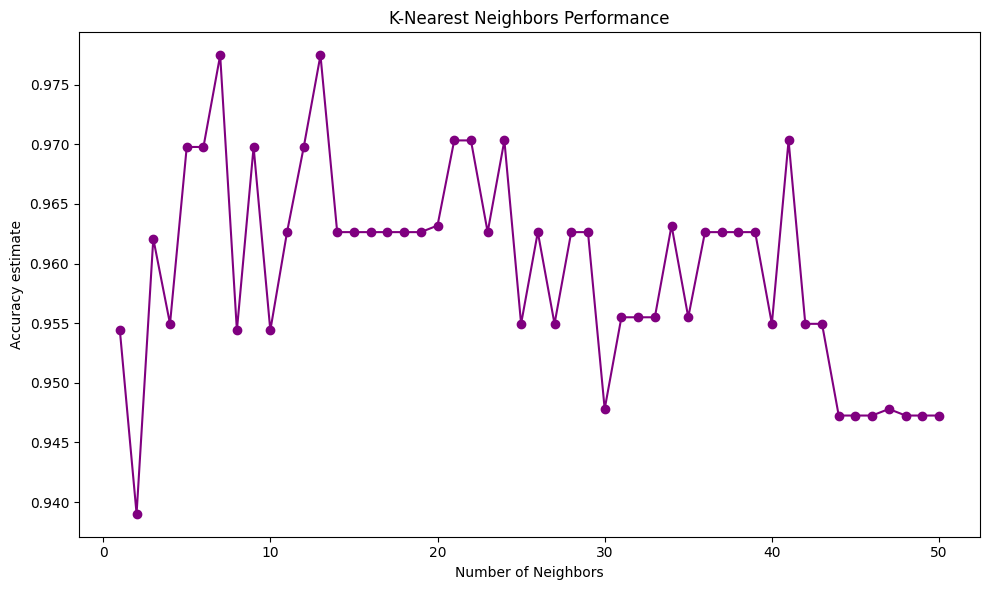

In [149]:
#I will create a plot for illustration 

# Create the plot
plt.figure(figsize=(10, 6))

# Plot mean test scores with error bars
plt.plot(accuracy_grid['param_n_neighbors'], accuracy_grid['mean_test_score'], '-o', color='purple')

# Add labels and legend
plt.xlabel('Number of Neighbors')
plt.ylabel('Accuracy estimate')
plt.title('K-Nearest Neighbors Performance')
plt.tight_layout()
plt.show()

In [150]:

# I used Google to build this query
# here I build Boolean serience
accuracy_grid['rank_test_score'] == 1

0     False
1     False
2     False
3     False
4     False
5     False
6      True
7     False
8     False
9     False
10    False
11    False
12     True
13    False
14    False
15    False
16    False
17    False
18    False
19    False
20    False
21    False
22    False
23    False
24    False
25    False
26    False
27    False
28    False
29    False
30    False
31    False
32    False
33    False
34    False
35    False
36    False
37    False
38    False
39    False
40    False
41    False
42    False
43    False
44    False
45    False
46    False
47    False
48    False
49    False
Name: rank_test_score, dtype: bool

In [151]:
# filter the accuracy grid when rank_test_score =1 
best_K_row = accuracy_grid[accuracy_grid['rank_test_score'] == 1]
best_K_row

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_neighbors,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,mean_test_score,std_test_score,rank_test_score
6,0.001373,0.002278,0.002973,0.004391,7,{'n_neighbors': 7},1.0,0.928571,1.0,0.923077,0.923077,1.0,1.0,1.000000,1.0,1.0,0.977473,0.034441,1
12,0.001875,0.004986,0.003129,0.006259,13,{'n_neighbors': 13},1.0,0.928571,1.0,1.000000,0.923077,1.0,1.0,0.923077,1.0,1.0,0.977473,0.034441,1


#### **Question 4:**
#### Model evaluation

Using the best value for `n_neighbors`, fit a KNN model on the training data and evaluate its performance on the test set using `accuracy_score`.

In [152]:
# Your code here...
knn = KNeighborsClassifier(n_neighbors=7)   
knn.fit(X=wine_df_train[column_names_list_exresponse], y=wine_df_train["class"]) #fitting the model when K=7 [train data]


,n_neighbors,7
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [153]:
wine_df_test['predicted class'] = knn.predict(wine_df_test[column_names_list_exresponse]) # testing the model on test data 
wine_df_test [['predicted class', 'class']]

,predicted class,class
102,1,1
84,1,1
96,2,1
65,0,1
79,1,1
17,0,0
109,1,1
113,1,1
28,0,0
159,2,2


In [154]:
# evaluate based on accuracy score
knn.score(
    wine_df_test[column_names_list_exresponse], wine_df_test['class']
)

0.9333333333333333

In [155]:
##The test dataset contains 42 correct predictions out of 45, indicating 3 cases where the predicted and actual classes are incompatible.
(42 / 45) *100

93.33333333333333

# Criteria


| **Criteria**                                           | **Complete**                                      | **Incomplete**                                    |
|--------------------------------------------------------|---------------------------------------------------|--------------------------------------------------|
| **Data Inspection**                                    | Data is inspected for number of variables, observations and data types. | Data inspection is missing or incomplete.         |
| **Data Scaling**                                       | Data scaling or normalization is applied where necessary (e.g., using `StandardScaler`). | Data scaling or normalization is missing or incorrectly applied. |
| **Model Initialization**                               | The KNN model is correctly initialized and a random seed is set for reproducibility.            | The KNN model is not initialized, is incorrect, or lacks a random seed for reproducibility. |
| **Parameter Grid for `n_neighbors`**                   | The parameter grid for `n_neighbors` is correctly defined. | The parameter grid is missing or incorrectly defined. |
| **Cross-Validation Setup**                             | Cross-validation is set up correctly with 10 folds. | Cross-validation is missing or incorrectly set up. |
| **Best Hyperparameter (`n_neighbors`) Selection**       | The best value for `n_neighbors` is identified using the grid search results. | The best `n_neighbors` is not selected or incorrect. |
| **Model Evaluation on Test Data**                      | The model is evaluated on the test data using accuracy. | The model evaluation is missing or uses the wrong metric. |


## Submission Information

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.

### Note:

If you like, you may collaborate with others in the cohort. If you choose to do so, please indicate with whom you have worked with in your pull request by tagging their GitHub username. Separate submissions are required.

### Submission Parameters:
* Submission Due Date: `11:59 PM - 11/24/2025`
* The branch name for your repo should be: `assignment-1`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_1.ipynb) should be populated and should be the only change in your pull request.
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/LCR/pull/<pr_id>`
    * Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.

Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.

If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#dc2-help`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.
